# TFM - Predicción de morosidad y scoring crediticio

## 1. Inicialización del entorno y carga de datos

In [32]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Configuración de visualización
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

# Semilla reproducible
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [7]:
import os

os.makedirs("TFM-credit-risk/data", exist_ok=True)
os.makedirs("TFM-credit-risk/notebooks", exist_ok=True)

In [5]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [8]:
import shutil

shutil.move("data.csv", "TFM-credit-risk/data/data.csv")

'TFM-credit-risk/data/data.csv'

In [9]:
%cd TFM-credit-risk

/content/TFM-credit-risk


In [10]:
import os
os.getcwd()


'/content/TFM-credit-risk'

In [33]:
df = pd.read_csv("data/data.csv")

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (8399, 14)


,mora,atraso,vivienda,edad,dias_lab,exp_sf,nivel_ahorro,ingreso,linea_sf,deuda_sf,score,zona,clasif_sbs,nivel_educ
0,0,235,FAMILIAR,30,3748,93.000,5,3500.000,NaN,0.000,214,Lima,4,UNIVERSITARIA
1,0,18,FAMILIAR,32,4598,9.000,12,900.000,1824.670,1933.750,175,La Libertad,1,TECNICA
2,0,0,FAMILIAR,26,5148,8.000,2,2400.000,2797.380,188.290,187,Lima,0,UNIVERSITARIA
3,0,0,FAMILIAR,36,5179,20.000,12,2700.000,NaN,0.000,187,Ancash,0,TECNICA
4,0,0,FAMILIAR,46,3960,NaN,1,3100.000,2000.000,11010.650,189,Lima,0,TECNICA


## 2. Exploración

In [34]:
print("Resumen de información del dataset:\n")
df.info()

print("\nResumen de estadísticas descriptivas del dataset:\n")
df.describe()

Resumen de información del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8399 entries, 0 to 8398
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mora          8399 non-null   int64  
 1   atraso        8399 non-null   int64  
 2   vivienda      8399 non-null   object 
 3   edad          8399 non-null   int64  
 4   dias_lab      8399 non-null   int64  
 5   exp_sf        6569 non-null   float64
 6   nivel_ahorro  8399 non-null   int64  
 7   ingreso       8399 non-null   float64
 8   linea_sf      7272 non-null   float64
 9   deuda_sf      7938 non-null   float64
 10  score         8399 non-null   int64  
 11  zona          8399 non-null   object 
 12  clasif_sbs    8399 non-null   int64  
 13  nivel_educ    8399 non-null   object 
dtypes: float64(4), int64(7), object(3)
memory usage: 918.8+ KB

Resumen de estadísticas descriptivas del dataset:



,mora,atraso,edad,dias_lab,exp_sf,nivel_ahorro,ingreso,linea_sf,deuda_sf,score,clasif_sbs
count,8399.000,8399.000,8399.000,8399.000,6569.000,8399.000,8399.000,7272.000,7938.000,8399.000,8399.000
mean,0.704,4.463,36.399,5555.889,32.402,10.593,4350.407,11987.241,6110.724,196.620,0.564
std,0.456,14.271,9.826,2153.244,32.866,3.375,5367.059,21322.802,11177.990,19.544,0.906
min,0.000,0.000,20.000,2956.000,0.000,0.000,123.700,0.000,0.000,134.000,0.000
25%,0.000,0.000,29.000,4174.000,7.000,12.000,1366.670,1169.372,478.320,182.000,0.000
50%,1.000,0.000,34.000,4904.000,20.000,12.000,2400.000,4030.120,2258.755,197.000,0.000
75%,1.000,2.000,42.000,6182.000,51.000,12.000,4900.000,12086.627,5755.150,212.000,1.000
max,1.000,245.000,85.000,20700.000,130.000,12.000,30000.000,121543.400,57094.380,266.000,4.000


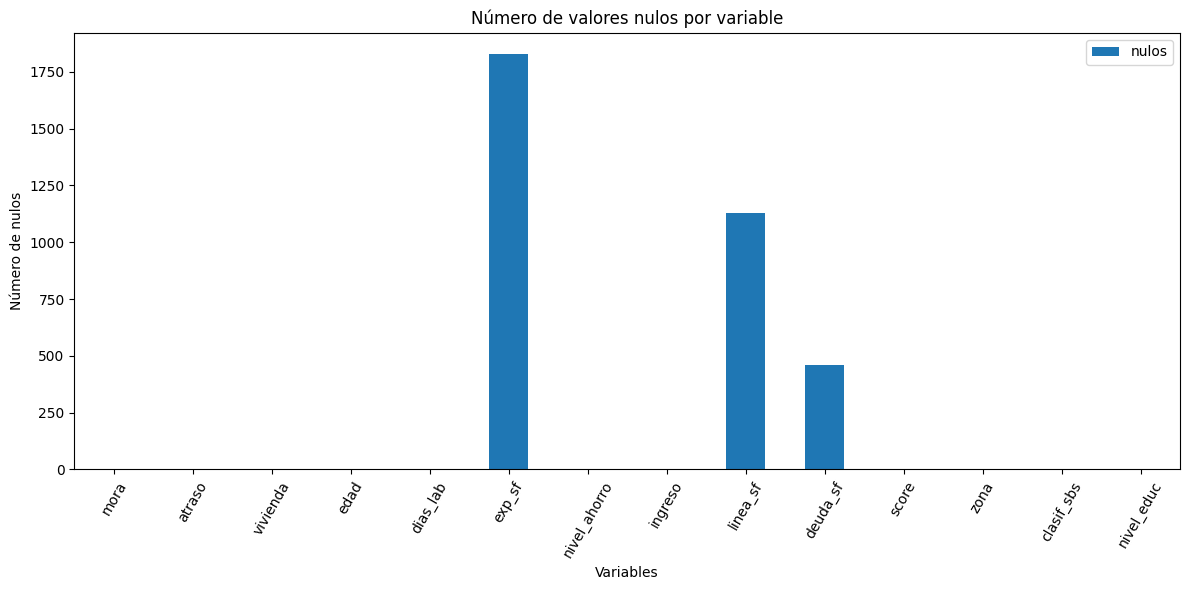

Resumen de variables con valores nulos:

exp_sf      1830
linea_sf    1127
deuda_sf     461
dtype: int64


In [35]:
missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    "nulos": missing_values
})

ax = missing_df.plot(kind="bar", figsize=(12,6))

ax.set_title("Número de valores nulos por variable")
ax.set_xlabel("Variables")
ax.set_ylabel("Número de nulos")

plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

print("Resumen de variables con valores nulos:\n")
print(missing_values[missing_values > 0].sort_values(ascending=False))

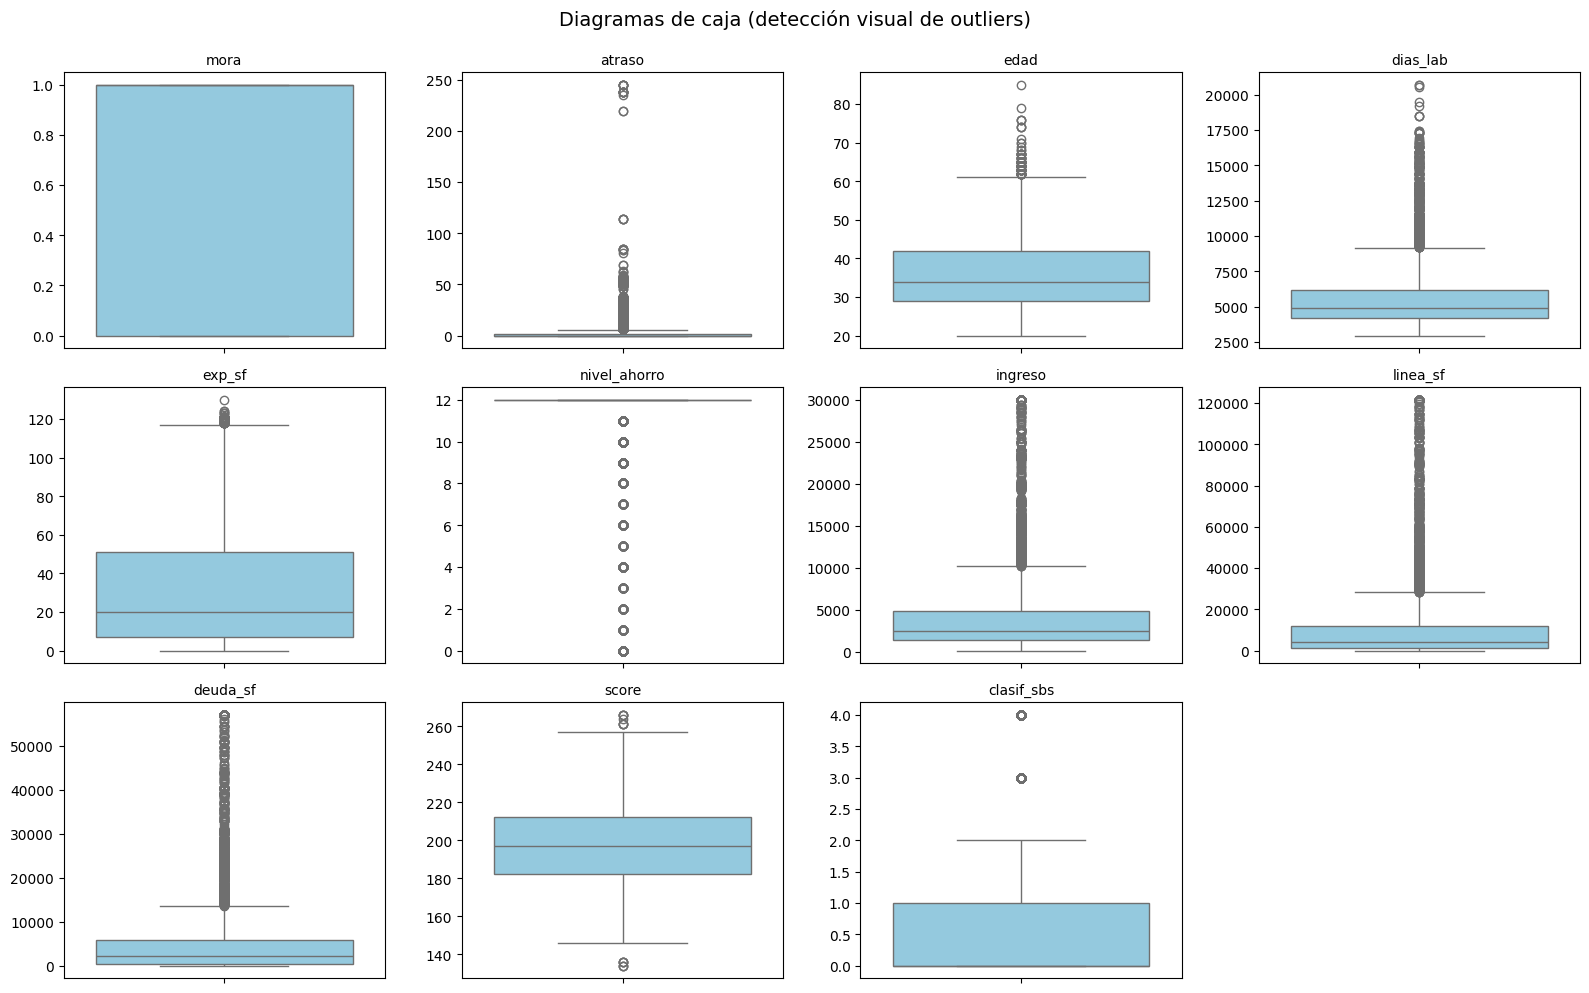

In [36]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

n = len(numeric_cols)
cols = 4
rows = (n + cols - 1) // cols

plt.figure(figsize=(4*cols, 3.2*rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col, fontsize=10)
    plt.ylabel("")

plt.tight_layout()
plt.suptitle("Diagramas de caja (detección visual de outliers)", y=1.03, fontsize=14)

plt.show()

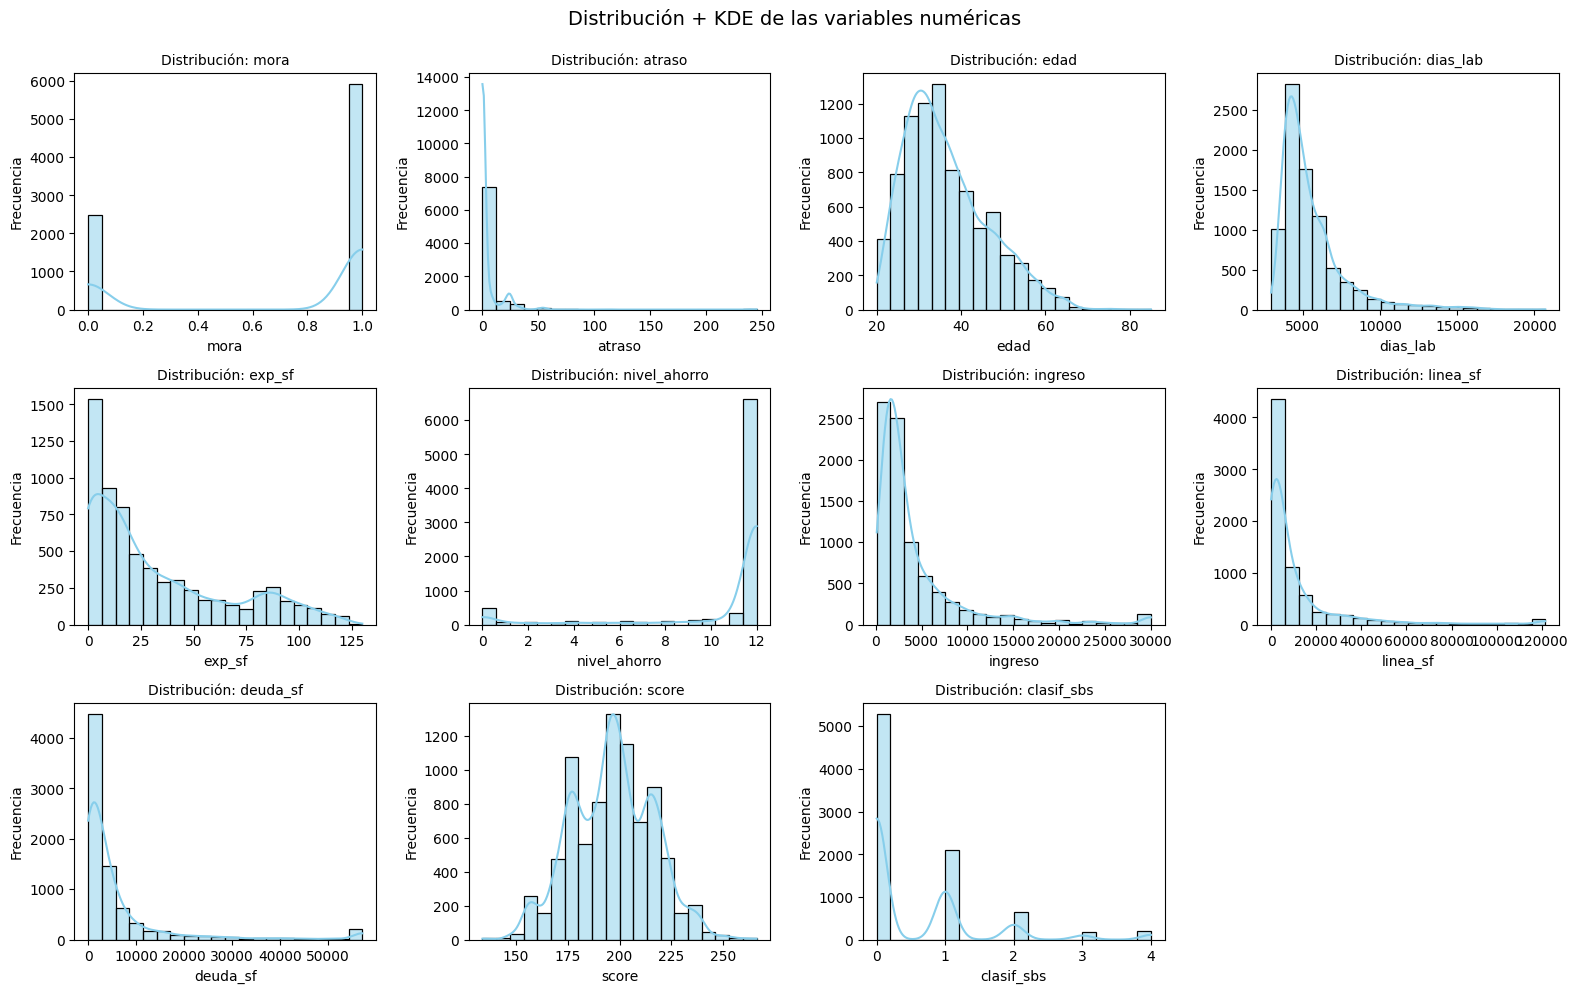

In [37]:
n = len(numeric_cols)
cols = 4
rows = (n + cols - 1) // cols

plt.figure(figsize=(4*cols, 3.2*rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(df[col], bins=20, kde=True, edgecolor='black', color='skyblue')
    plt.title(f"Distribución: {col}", fontsize=10)
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.suptitle("Distribución + KDE de las variables numéricas", y=1.03, fontsize=14)

plt.show()

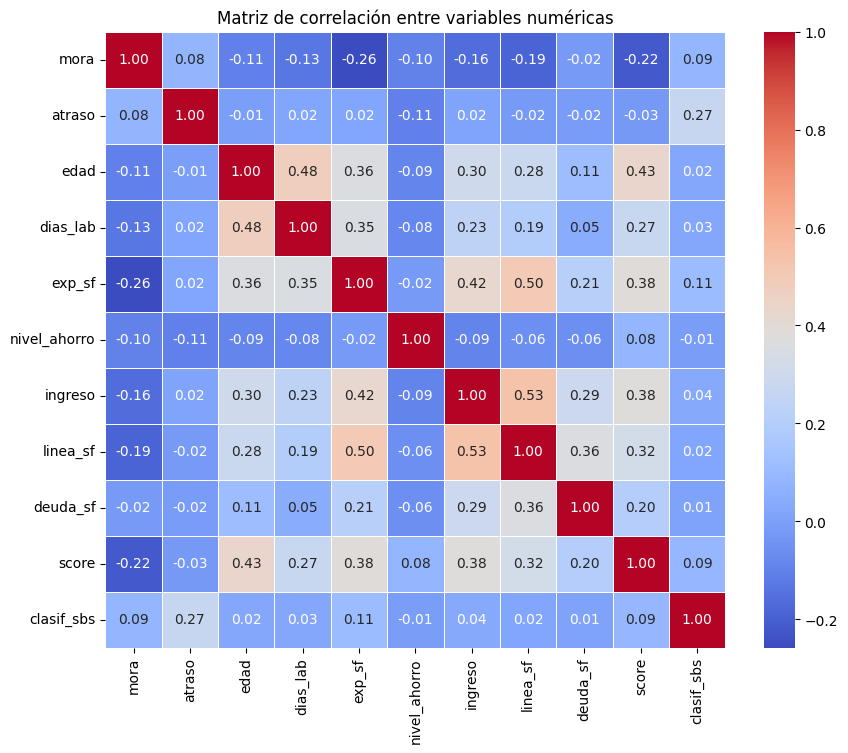

In [38]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlación entre variables numéricas")

plt.show()

## 3. Preprocesamiento

In [39]:
df["exp_sf"].fillna(df["exp_sf"].median(), inplace=True)
df["linea_sf"].fillna(df["linea_sf"].median(), inplace=True)
df["deuda_sf"].fillna(df["deuda_sf"].median(), inplace=True)

In [40]:
print("Valores nulos después de la imputación:\n")
print(df.isnull().sum())

Valores nulos después de la imputación:

mora            0
atraso          0
vivienda        0
edad            0
dias_lab        0
exp_sf          0
nivel_ahorro    0
ingreso         0
linea_sf        0
deuda_sf        0
score           0
zona            0
clasif_sbs      0
nivel_educ      0
dtype: int64


In [41]:
df["log_ingreso"] = np.log1p(df["ingreso"])
df["log_linea_sf"] = np.log1p(df["linea_sf"])
df["log_deuda_sf"] = np.log1p(df["deuda_sf"])
df["log_atraso"] = np.log1p(df["atraso"])
df["log_exp_sf"] = np.log1p(df["exp_sf"])

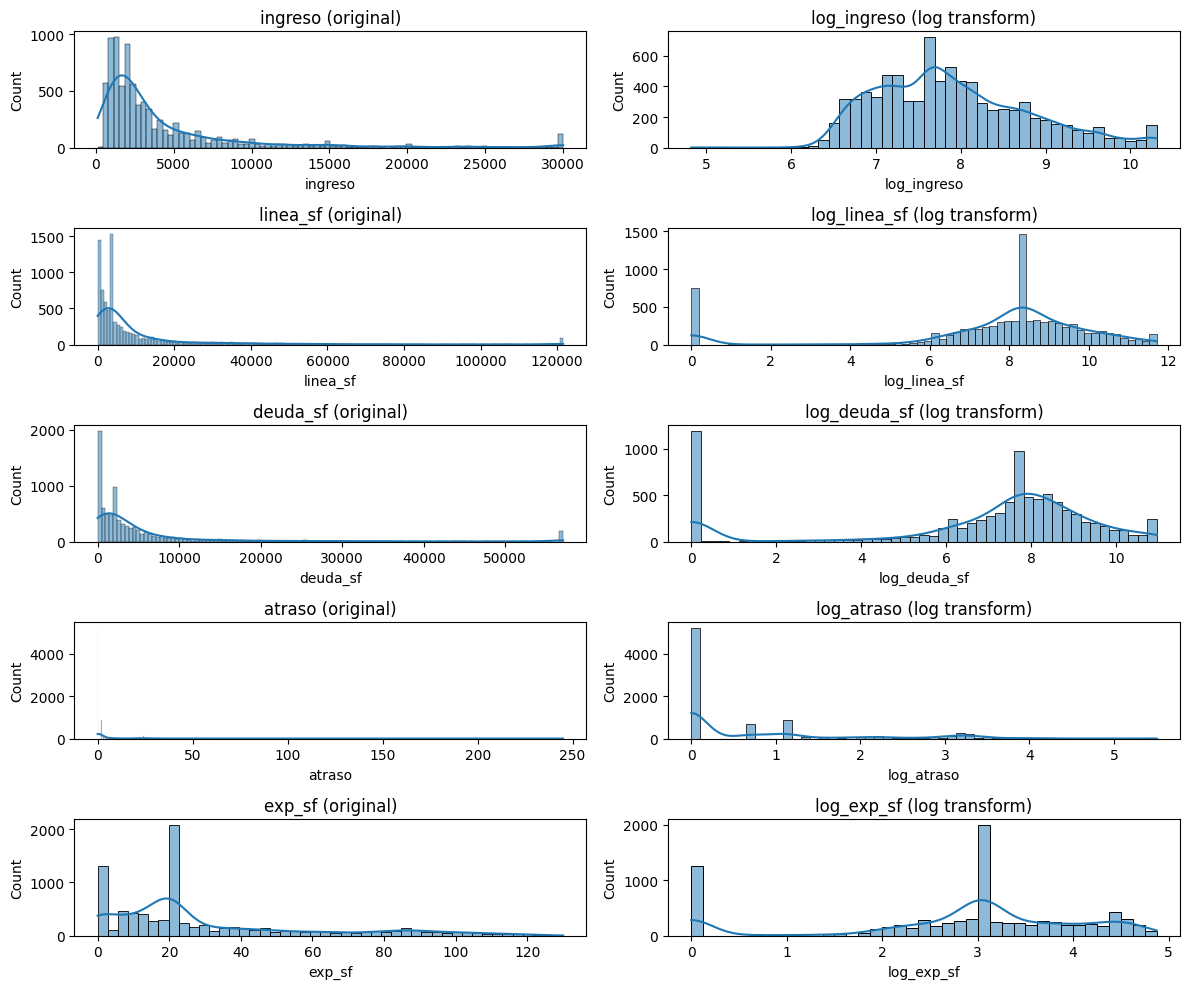

In [42]:
log_pairs = [
    ("ingreso", "log_ingreso"),
    ("linea_sf", "log_linea_sf"),
    ("deuda_sf", "log_deuda_sf"),
    ("atraso", "log_atraso"),
    ("exp_sf", "log_exp_sf")
]

plt.figure(figsize=(12,10))

for i, (orig, log) in enumerate(log_pairs, 1):

    plt.subplot(len(log_pairs), 2, 2*i-1)
    sns.histplot(df[orig], kde=True)
    plt.title(f"{orig} (original)")

    plt.subplot(len(log_pairs), 2, 2*i)
    sns.histplot(df[log], kde=True)
    plt.title(f"{log} (log transform)")

plt.tight_layout()
plt.show()

In [43]:
cols_replace = ['ingreso','linea_sf','deuda_sf','atraso','exp_sf']

for col in cols_replace:
    df.drop(columns=col, inplace=True)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8399 entries, 0 to 8398
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mora          8399 non-null   int64  
 1   vivienda      8399 non-null   object 
 2   edad          8399 non-null   int64  
 3   dias_lab      8399 non-null   int64  
 4   nivel_ahorro  8399 non-null   int64  
 5   score         8399 non-null   int64  
 6   zona          8399 non-null   object 
 7   clasif_sbs    8399 non-null   int64  
 8   nivel_educ    8399 non-null   object 
 9   log_ingreso   8399 non-null   float64
 10  log_linea_sf  8399 non-null   float64
 11  log_deuda_sf  8399 non-null   float64
 12  log_atraso    8399 non-null   float64
 13  log_exp_sf    8399 non-null   float64
dtypes: float64(5), int64(6), object(3)
memory usage: 918.8+ KB


In [22]:

df = df.copy()

nivel_educ_map = {
    "SIN EDUCACION": 0,
    "SECUNDARIA": 1,
    "TECNICA": 2,
    "UNIVERSITARIA": 3
}

df["nivel_educ"] = df["nivel_educ"].map(nivel_educ_map)

print("Codificación aplicada a 'nivel_educ':")
print(nivel_educ_map)

df = pd.get_dummies(
    df,
    columns=["vivienda", "zona"],
    drop_first=True
)

bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

print("\nDimensión del dataset después de la codificación:")
print(df.shape)

print("\nTipos de datos:")
print(df.dtypes.value_counts())

print("\nVariables categóricas restantes:")
print(df.select_dtypes(include="object").columns.tolist())

print("\nPrimeras filas del dataset:")
print(df.head())

Codificación aplicada a 'nivel_educ':
{'SIN EDUCACION': 0, 'SECUNDARIA': 1, 'TECNICA': 2, 'UNIVERSITARIA': 3}

Dimensión del dataset después de la codificación:
(8399, 43)

Tipos de datos:
int64      34
float64     9
Name: count, dtype: int64

Variables categóricas restantes:
[]

Primeras filas del dataset:
   mora  atraso  edad  dias_lab  exp_sf  nivel_ahorro  ingreso  linea_sf  \
0     0     235    30      3748  93.000             5 3500.000  4030.120   
1     0      18    32      4598   9.000            12  900.000  1824.670   
2     0       0    26      5148   8.000             2 2400.000  2797.380   
3     0       0    36      5179  20.000            12 2700.000  4030.120   
4     0       0    46      3960  20.000             1 3100.000  2000.000   

   deuda_sf  score  clasif_sbs  nivel_educ  log_ingreso  log_linea_sf  \
0     0.000    214           4           3        8.161         8.302   
1  1933.750    175           1           2        6.804         7.510   
2   188.290    

## 4. Preparación para modelado

In [23]:
X = df.drop("mora", axis=1)
y = df["mora"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
# StandardScaler
scaler_standard = StandardScaler()
X_train_standard = scaler_standard.fit_transform(X_train)
X_test_standard = scaler_standard.transform(X_test)

# MinMaxScaler
scaler_minmax = MinMaxScaler()
X_train_minmax = scaler_minmax.fit_transform(X_train)
X_test_minmax = scaler_minmax.transform(X_test)

# RobustScaler
scaler_robust = RobustScaler()
X_train_robust = scaler_robust.fit_transform(X_train)
X_test_robust = scaler_robust.transform(X_test)